In [1]:
#Basic libraries
import numpy as np
import pandas as pd

#Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers.core import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils.np_utils import to_categorical
from keras.wrappers.scikit_learn import KerasClassifier

In [2]:
fashion_train = pd.read_csv("fashion-mnist_train.csv")
fashion_test = pd.read_csv("fashion-mnist_test.csv")

In [3]:
fashion_train.shape
#Data is already flatenned

(60000, 785)

In [4]:
#split input and output from the test & train data
#label is the output column in dataset

X_train_fashion = fashion_train.drop('label',axis=1)
y_train_fashion = fashion_train['label']
X_test_fashion = fashion_test.drop('label',axis=1)
y_test_fashion = fashion_test['label']

In [5]:
X_train_fashion.shape

(60000, 784)

In [6]:
X_test_fashion.shape

(10000, 784)

In [7]:
#Reshaping the dataset to see as imgae (if data set is in 3D already, we can direcly use data to visualize)
#784 columns are converted as 28x28 pixel table or matrix.
#-1 denotes that all rows in the particular dataset.
x_train_reshape = X_train_fashion.values.reshape(-1,28,28)
x_test_reshape = X_test_fashion.values.reshape(-1,28,28)

In [8]:
x_train_reshape.shape

(60000, 28, 28)

In [9]:
x_test_reshape.shape

(10000, 28, 28)

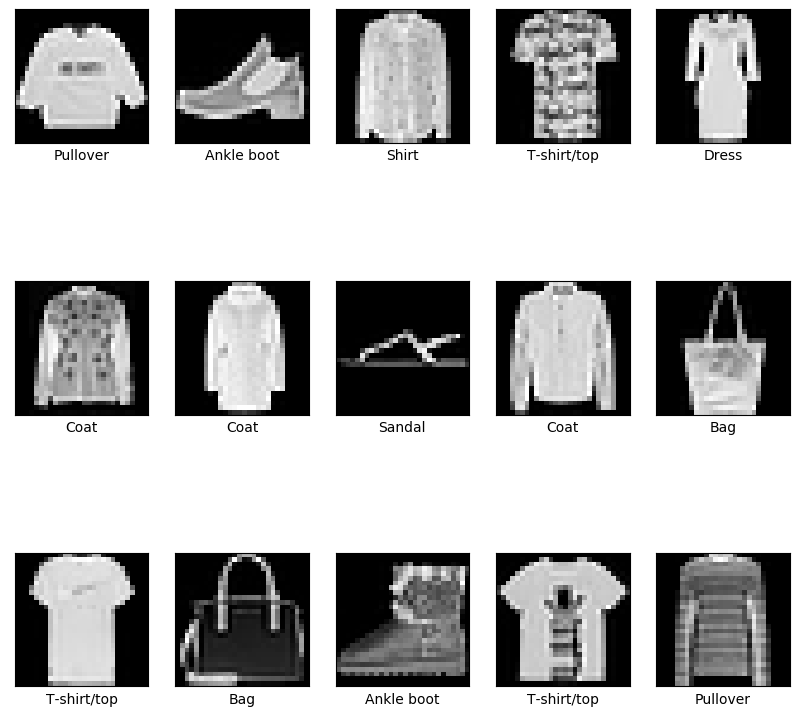

In [10]:
#Let's visualize the data

#Names of clothing accessories in order 
col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,10))
for i in range(15): #just first 15 image
    plt.subplot(3,5,i+1) # 3X5 (1.e) 3 rows & 5 columns ploting the image. (i+1) is postion of that image
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_reshape[i], cmap='gray') #0 to 14 position in x_train_reshape list
    plt.xlabel(col_names[y_train_fashion[i]]) # respective output for input and respective name for 0 to 14 position in col_names
plt.show()

In [11]:
y_train_fashion.shape

(60000,)

In [12]:
y_test_fashion.shape

(10000,)

In [13]:
#Since the output is in 1D, we need to convert it by onehot encoding

y_train_fashion = to_categorical(y_train_fashion, num_classes = 10)
y_test_fashion = to_categorical(y_test_fashion, num_classes = 10)

In [14]:
#Creating base neural network

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)), #128 is neuron. (always 2 power n)
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    #Hidden layer 1
    layers.Dense(24, activation='relu'), #same input shape from previous line output. so no need to mention again.
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    #Hidden layer 2
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    #output layer
    layers.Dense(10,activation = 'softmax')
])

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 24)                3096      
                                                                 
 dropout_1 (Dropout)         (None, 24)                0         
                                                                 
 batch_normalization_1 (Batc  (None, 24)               96        
 hNormalization)                                        

In [15]:
#compiling the model
#these are playable hypertuning paramenters
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics = ["accuracy"])

In [16]:
#Fitting the model
history = model.fit(X_train_fashion, y_train_fashion, batch_size = 100, epochs=30, validation_data = (X_test_fashion, y_test_fashion))

Epoch 1/30
600/600 [==============================] - 5s 6ms/step - loss: 1.1101 - accuracy: 0.6305 - val_loss: 0.5529 - val_accuracy: 0.8031
Epoch 2/30
600/600 [==============================] - 3s 5ms/step - loss: 0.7180 - accuracy: 0.7578 - val_loss: 0.4635 - val_accuracy: 0.8352
Epoch 3/30
600/600 [==============================] - 3s 5ms/step - loss: 0.6546 - accuracy: 0.7795 - val_loss: 0.4973 - val_accuracy: 0.8271
Epoch 4/30
600/600 [==============================] - 3s 5ms/step - loss: 0.6254 - accuracy: 0.7896 - val_loss: 0.4471 - val_accuracy: 0.8438
Epoch 5/30
600/600 [==============================] - 3s 6ms/step - loss: 0.6056 - accuracy: 0.7979 - val_loss: 0.4294 - val_accuracy: 0.8517
Epoch 6/30
600/600 [==============================] - 3s 6ms/step - loss: 0.5862 - accuracy: 0.8039 - val_loss: 0.4084 - val_accuracy: 0.8580
Epoch 7/30
600/600 [==============================] - 3s 5ms/step - loss: 0.5730 - accuracy: 0.8084 - val_loss: 0.4299 - val_accuracy: 0.8521
Epoch 

In [18]:
#loss function & accuracy
test_loss_fashion, test_acc_fashion = model.evaluate(X_test_fashion, y_test_fashion)

313/313 [==============================] - 1s 3ms/step - loss: 0.4387 - accuracy: 0.8774


In [20]:
print(f'Fashion MNIST Test accuracy: {round(test_acc_fashion,4)}')

Fashion MNIST Test accuracy: 0.8774


In [21]:
#predict the output for test data
y_predict_fash = model.predict(X_test_fashion)

In [22]:
y_predict_fash

array([[6.2740511e-01, 4.9906282e-04, 1.3504769e-02, ..., 1.0458445e-05,
        3.4609745e-04, 4.1671860e-06],
       [6.3255685e-09, 1.0000000e+00, 6.1228034e-10, ..., 2.7419764e-14,
        1.8305671e-11, 2.2097286e-11],
       [1.1529317e-02, 7.5449329e-04, 7.3056656e-01, ..., 1.5739362e-05,
        1.9434722e-03, 2.2697277e-05],
       ...,
       [1.3179828e-06, 4.5786143e-07, 1.0141359e-09, ..., 3.0893741e-09,
        9.9999762e-01, 2.4365153e-08],
       [1.3844193e-02, 6.3207612e-05, 9.9575042e-04, ..., 7.3206832e-04,
        9.7129917e-01, 2.3512803e-04],
       [1.4655295e-02, 4.5196462e-01, 2.7184039e-01, ..., 5.0196354e-04,
        8.0955550e-03, 2.6333702e-04]], dtype=float32)

In [23]:
#pick the max value among 10 output value for each pixel
y_predict_fash = np.argmax(y_predict_fash, axis=1)
y_predict_fash

array([0, 1, 2, ..., 8, 8, 1], dtype=int64)

In [24]:
# Now we have got single number as predicted output for each

In [25]:
#let's do the same for y_test
y_test_fashion

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], dtype=float32)

In [27]:
y_test_fash_eval = np.argmax(y_test_fashion, axis=1)
y_test_fash_eval

array([0, 1, 2, ..., 8, 8, 1], dtype=int64)

In [28]:
# Now we have got single number as test output for each.

In [30]:
#CONFUSION MATRIX
#we have classified ategorical output as 1 to 10. since this is classification problem, we see confusion matrix.

con_mat = confusion_matrix(y_test_fash_eval, y_predict_fash)

con_mat

array([[852,   0,  15,  51,   1,   0,  69,   0,  12,   0],
       [  2, 980,   1,  13,   0,   0,   4,   0,   0,   0],
       [ 10,   0, 824,  16,  86,   1,  60,   0,   3,   0],
       [ 22,   9,  10, 914,  29,   0,  13,   0,   3,   0],
       [  1,   0,  88,  29, 835,   0,  45,   0,   2,   0],
       [  0,   1,   0,   0,   0, 935,   0,  41,   3,  20],
       [203,   1, 103,  31,  82,   0, 570,   0,  10,   0],
       [  0,   0,   0,   0,   0,  17,   0, 950,   0,  33],
       [  3,   1,   8,   1,   5,   3,  11,   2, 966,   0],
       [  0,   0,   0,   0,   0,   9,   1,  42,   0, 948]], dtype=int64)

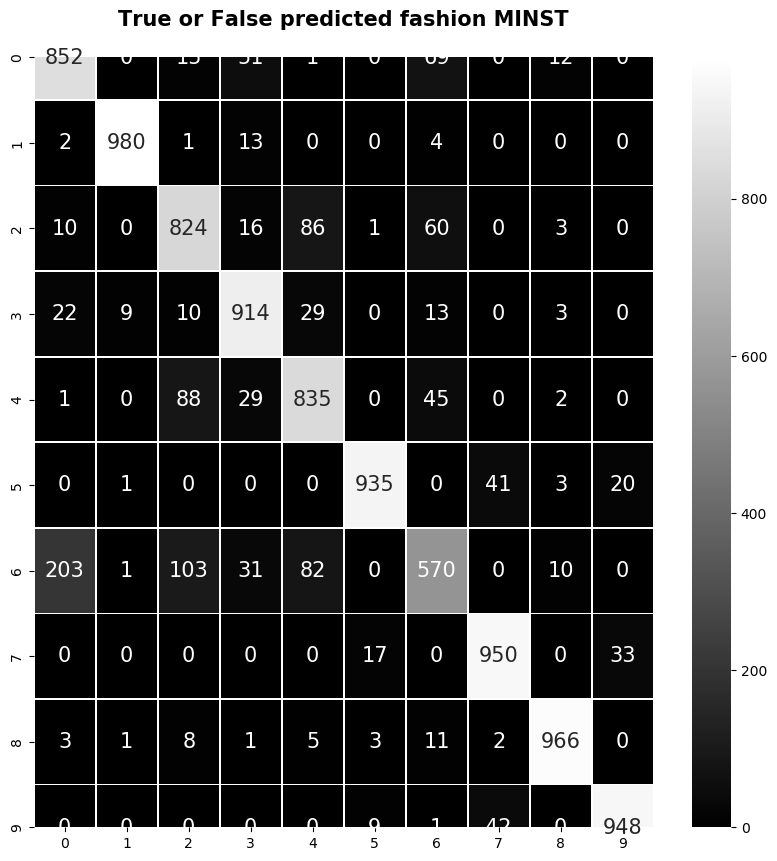

In [31]:
#Let's visualize the confusion matrix in heat map
plt.style.use('seaborn-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True, annot_kws={'size':15}, linewidth=0.5,fmt="d",cmap="gray")
plt.title('True or False predicted fashion MINST\n', fontweight='bold', fontsize=15)
plt.show()

In [34]:
# Classification report

from sklearn.metrics import classification_report
print(classification_report(y_test_fash_eval, y_predict_fash))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81      1000
           1       0.99      0.98      0.98      1000
           2       0.79      0.82      0.80      1000
           3       0.87      0.91      0.89      1000
           4       0.80      0.83      0.82      1000
           5       0.97      0.94      0.95      1000
           6       0.74      0.57      0.64      1000
           7       0.92      0.95      0.93      1000
           8       0.97      0.97      0.97      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [36]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


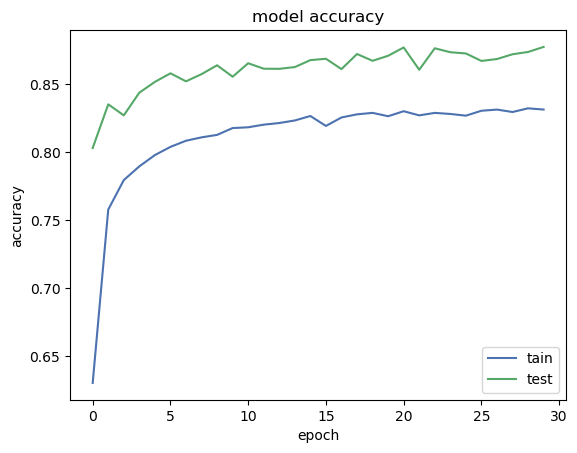

In [38]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['tain', 'test'], loc='best')
plt.show()

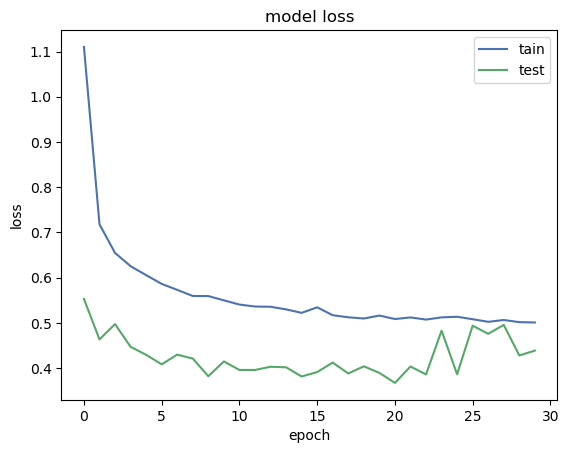

In [39]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['tain', 'test'], loc='best')
plt.show()

In [49]:
#Deployment check for single value from test input
#let's pick 0th position ans see what the predicted output is..
y_predict_single = model.predict(X_test_fashion.loc[[0],:].values)
#.loc to select row index 0
#The : means "all columns."
#.values → Converts the DataFrame slice into a NumPy array.
y_predict_single

array([[6.2740475e-01, 4.9906300e-04, 1.3504781e-02, 2.4142688e-02,
        1.8684270e-03, 7.0996393e-06, 3.3221251e-01, 1.0458460e-05,
        3.4609804e-04, 4.1671956e-06]], dtype=float32)

In [52]:
#select max for predicted
y_predict_single = np.argmax(y_predict_single, axis=1)
y_predict_single

#col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
#Input is X_test_fashion.loc[[0],:].values
#predicted output gives number 0 -- 0th position in our classes list is "T-shirt/top"

#it should be the same for 0th input position ##col_names[np.argmax(y_test_fashion[0])]## in test output as well.

array([0], dtype=int64)

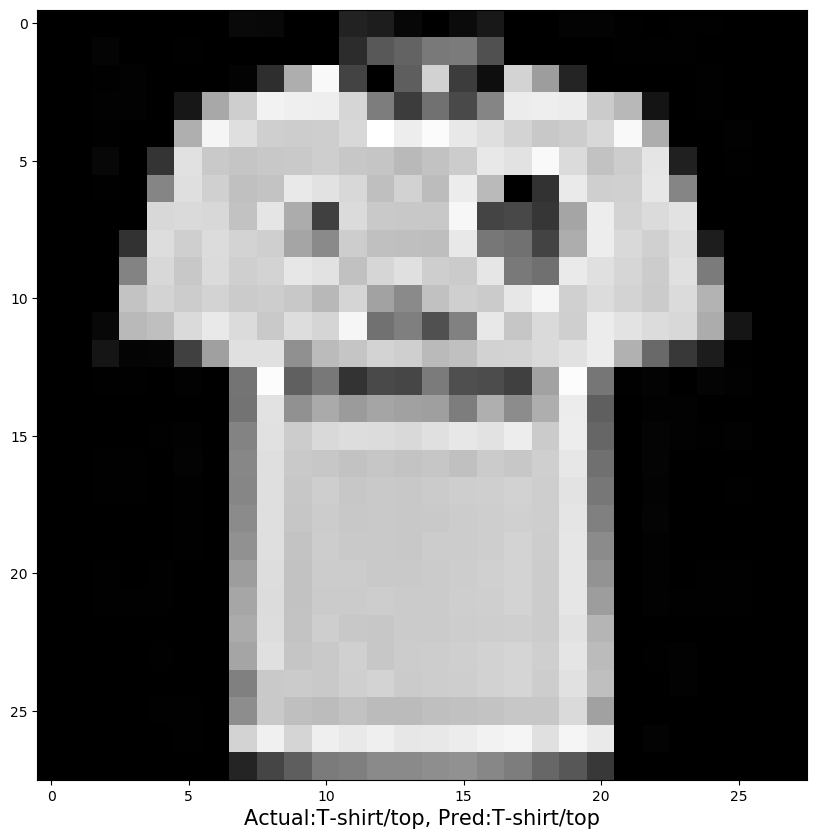

In [56]:
#Names of clothing accessories in order 
col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#Visualizing the image
plt.figure(figsize=(10,10))

#we use 0th position in x_test_rehaped dataset because we use the same input for y_predict_single in above step
plt.imshow(x_test_reshape[0], cmap='gray')
plt.xlabel(f'Actual:{col_names[np.argmax(y_test_fashion[0])]}, Pred:{col_names[y_predict_single[0]]}', fontsize=15)

plt.show()